In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [ ]:
df = pd.read_csv('/content/sample_data/upwork_jobs_final_categorized_synthetic_dates_36months.csv')

In [ ]:
df['published_date'] = pd.to_datetime(df['published_date'], errors='coerce')
df = df.dropna(subset=['published_date', 'category'])

# Extract month and group by category/month
df['month'] = df['published_date'].dt.to_period('M').dt.to_timestamp()
monthly_counts = df.groupby(['month', 'category']).size().unstack(fill_value=0)

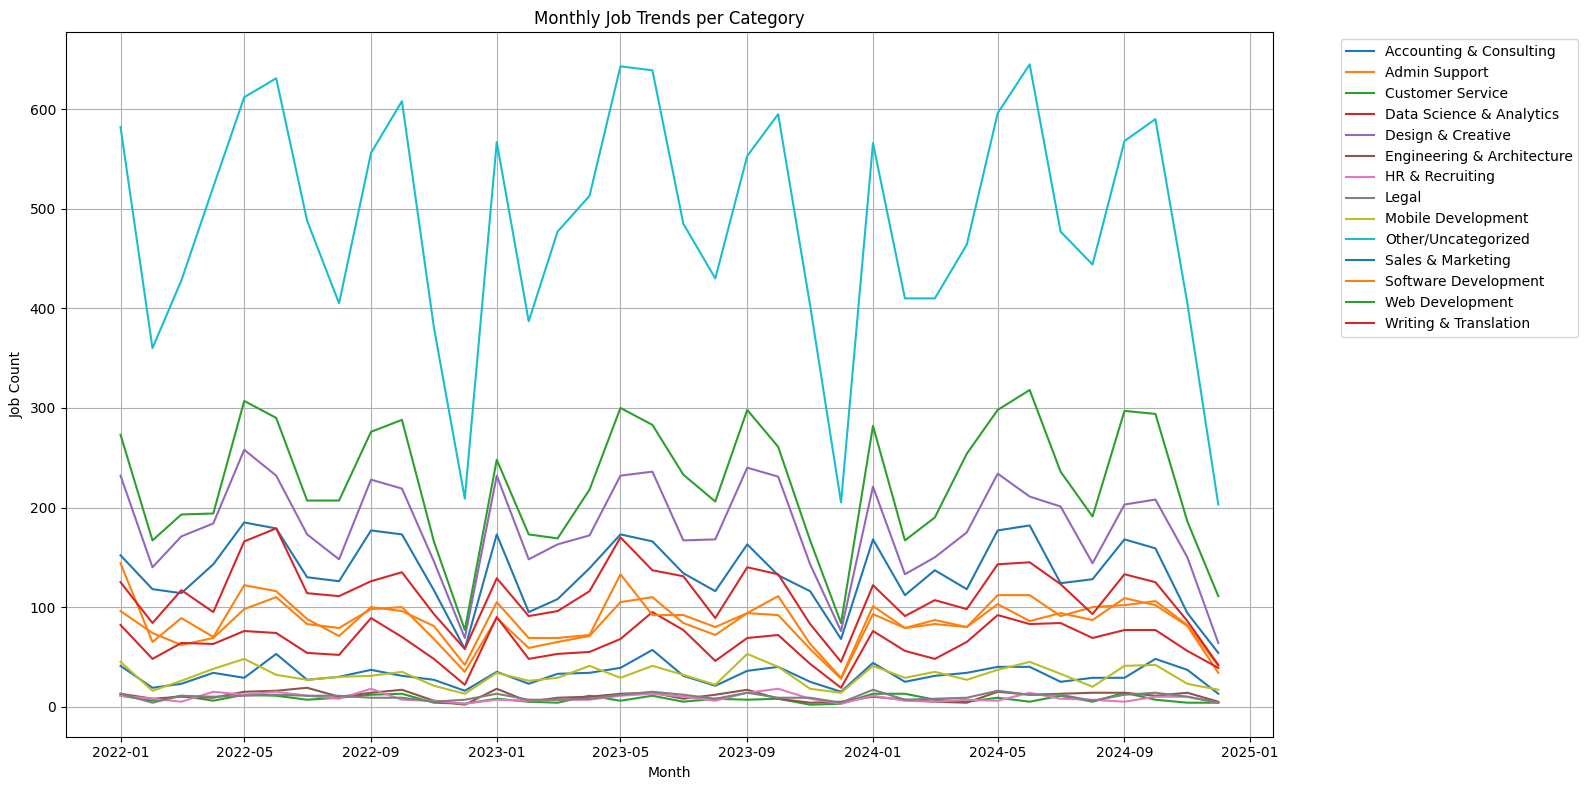

In [ ]:
plt.figure(figsize=(16, 8))
for category in monthly_counts.columns:
    plt.plot(monthly_counts.index, monthly_counts[category], label=category)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Monthly Job Trends per Category")
plt.xlabel("Month")
plt.ylabel("Job Count")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# --- Setup ---
predictions = {}
forecast_months = pd.date_range(monthly_counts.index[-1] + pd.offsets.MonthBegin(1), periods=6, freq='MS')

# You can adjust this to a lower number to make training faster
EPOCHS = 30
INPUT_WINDOW = 3

for i, category in enumerate(monthly_counts.columns):
    print(f"Training LSTM for category: {category} ({i+1}/{len(monthly_counts.columns)})")

    # --- Data prep ---
    data = monthly_counts[category].values.reshape(-1, 1)
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)

    generator = TimeseriesGenerator(scaled_data, scaled_data, length=INPUT_WINDOW, batch_size=1)

    # --- Model ---
    model = Sequential([
        LSTM(50, activation='relu', input_shape=(INPUT_WINDOW, 1)),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')

    model.fit(generator, epochs=EPOCHS, verbose=0)  # silent training

    # --- Forecast next 6 months ---
    pred_list = list(scaled_data[-INPUT_WINDOW:])
    for _ in range(6):
        x_input = np.array(pred_list[-INPUT_WINDOW:]).reshape((1, INPUT_WINDOW, 1))
        yhat = model.predict(x_input, verbose=0)[0][0]
        pred_list.append([yhat])  # Keep shape consistent

    forecast = scaler.inverse_transform(np.array(pred_list[INPUT_WINDOW:]).reshape(-1, 1)).flatten()
    predictions[category] = forecast

# --- Final forecast dataframe ---
forecast_df = pd.DataFrame(predictions, index=forecast_months)
print("✅ Forecasting complete.")

Training LSTM for category: Accounting & Consulting (1/14)
Training LSTM for category: Admin Support (2/14)
Training LSTM for category: Customer Service (3/14)
Training LSTM for category: Data Science & Analytics (4/14)
Training LSTM for category: Design & Creative (5/14)
Training LSTM for category: Engineering & Architecture (6/14)
Training LSTM for category: HR & Recruiting (7/14)
Training LSTM for category: Legal (8/14)
Training LSTM for category: Mobile Development (9/14)
Training LSTM for category: Other/Uncategorized (10/14)
Training LSTM for category: Sales & Marketing (11/14)
Training LSTM for category: Software Development (12/14)
Training LSTM for category: Web Development (13/14)
Training LSTM for category: Writing & Translation (14/14)
✅ Forecasting complete.


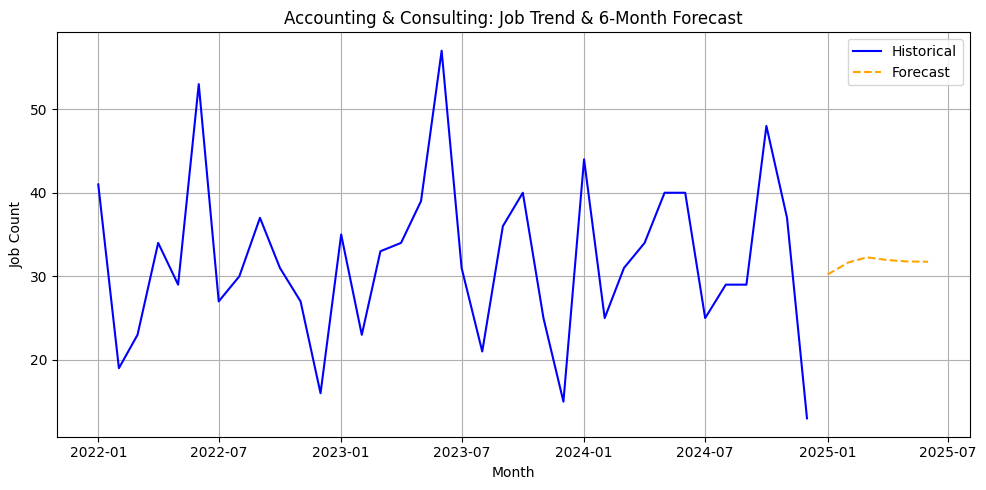

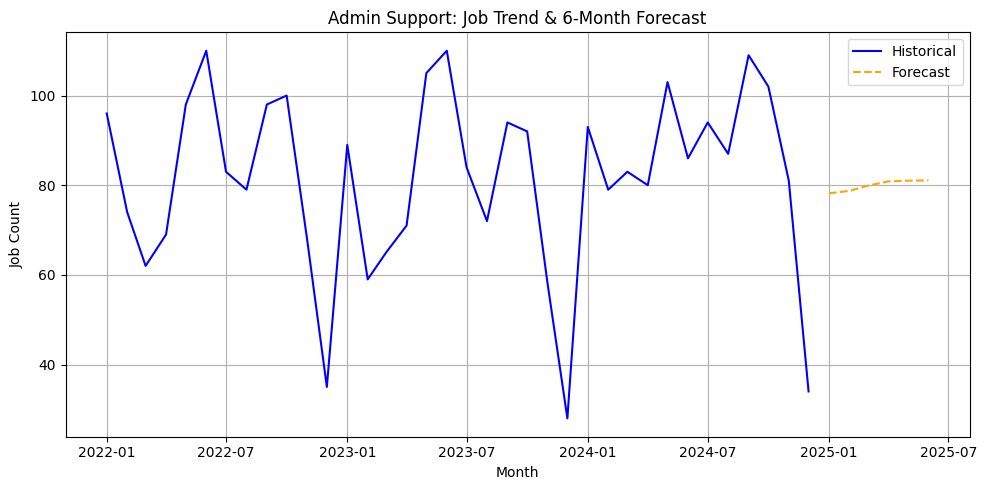

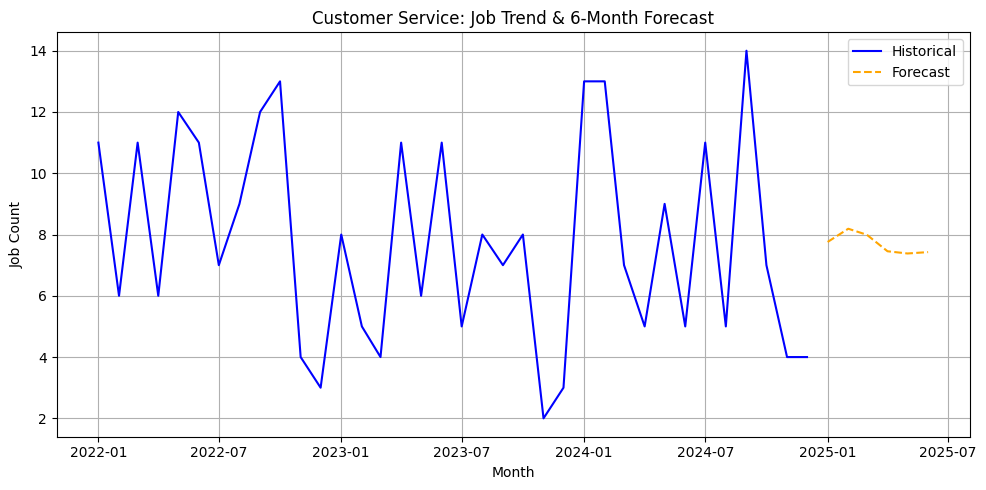

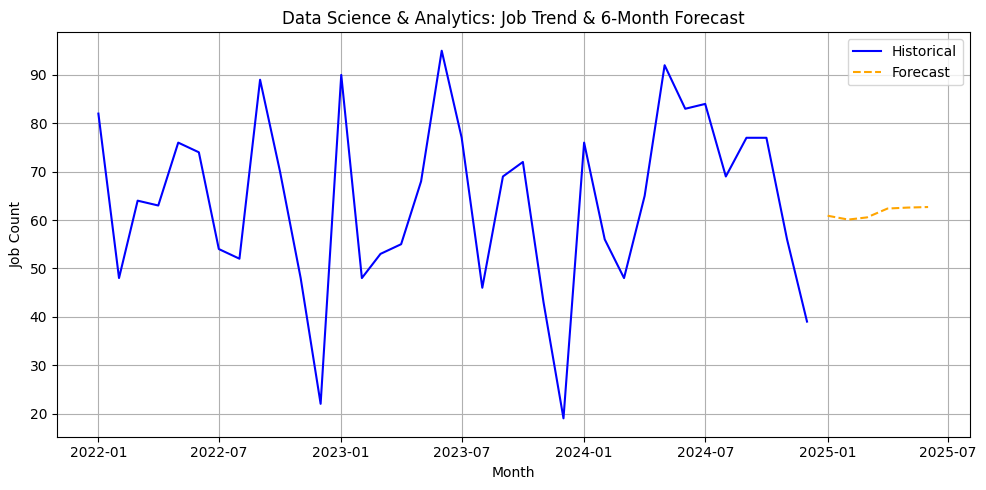

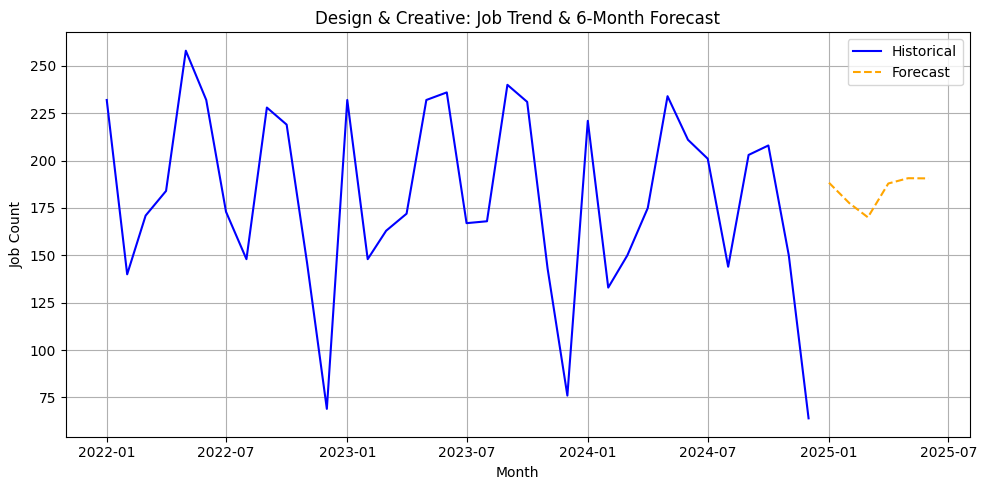

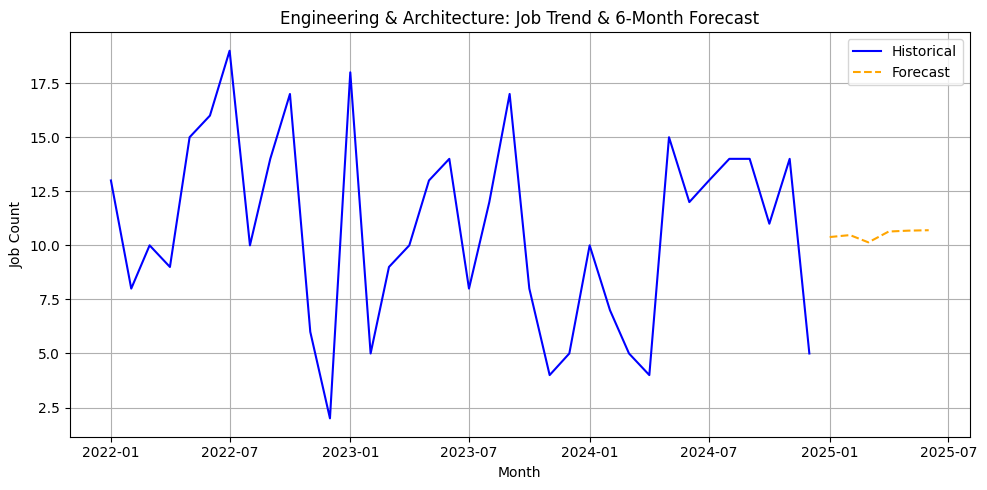

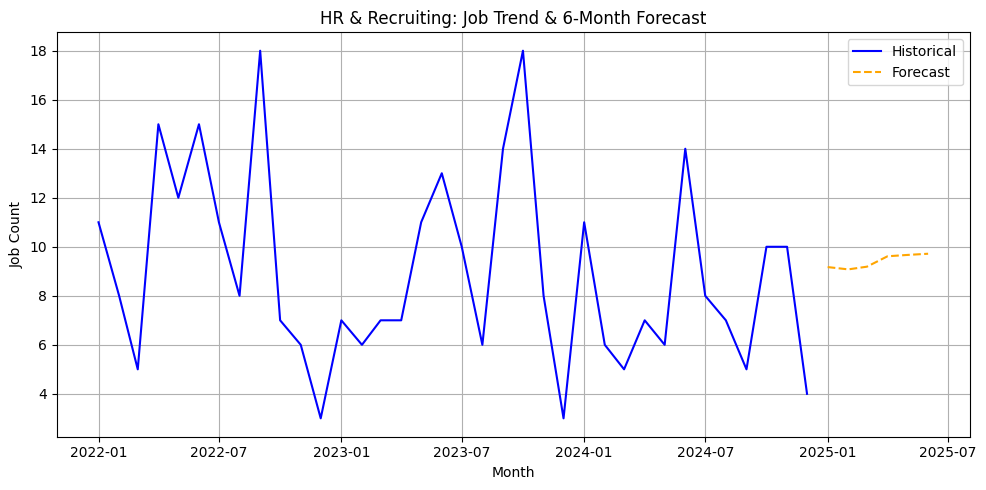

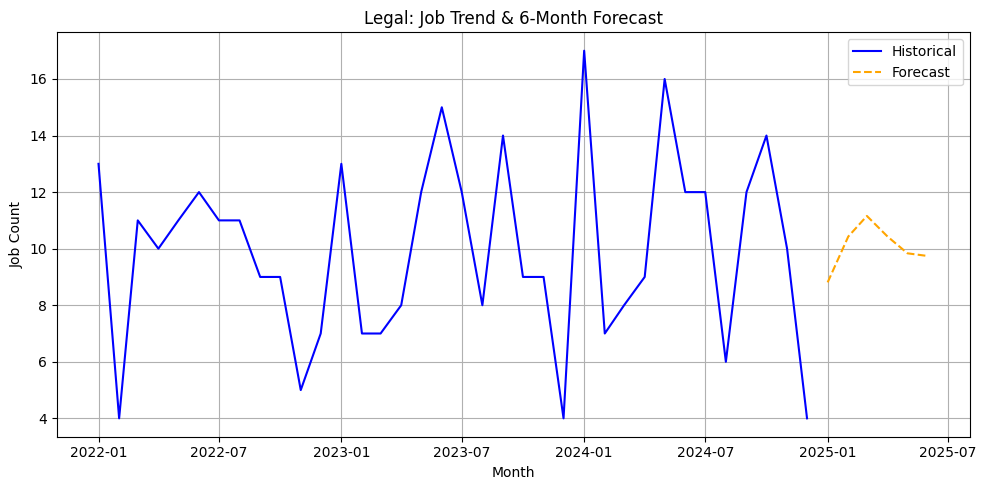

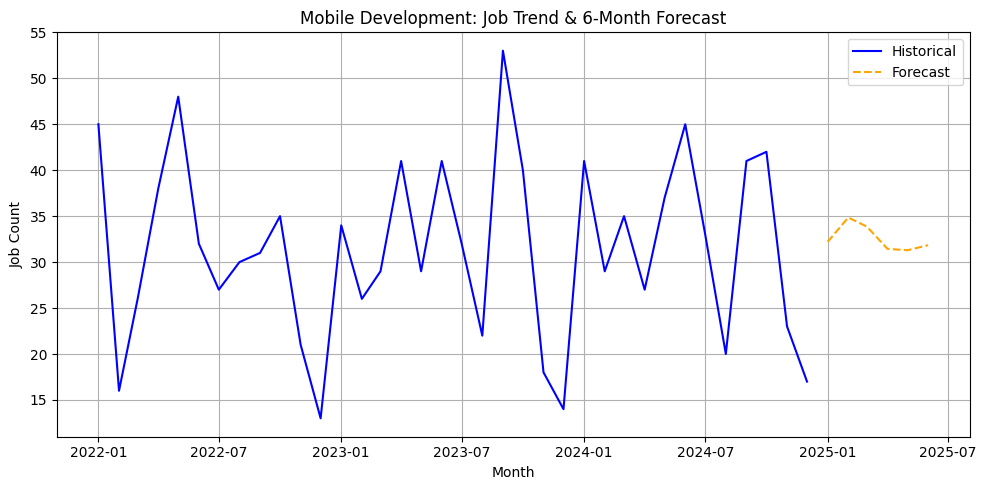

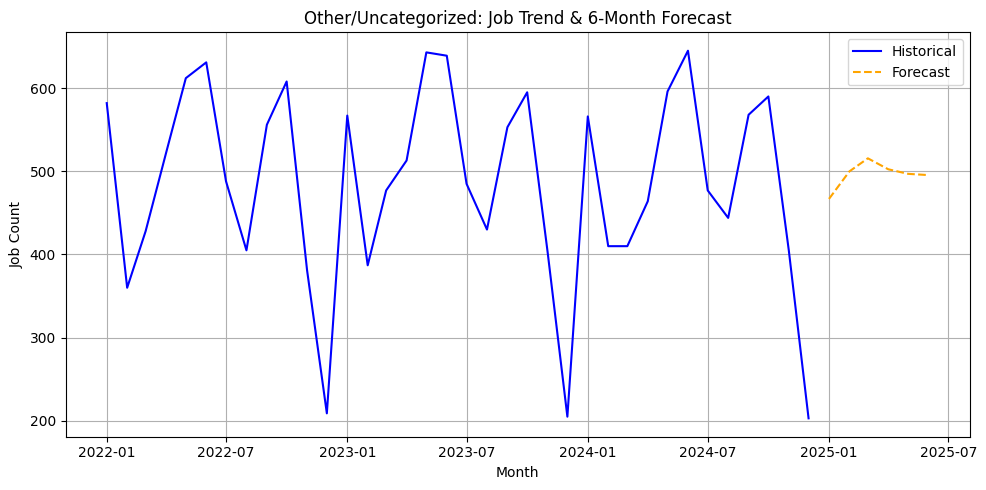

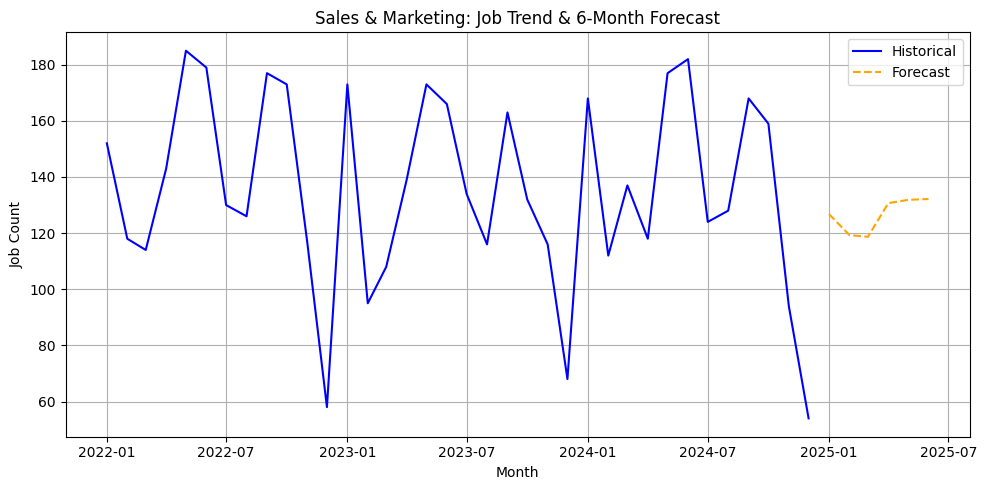

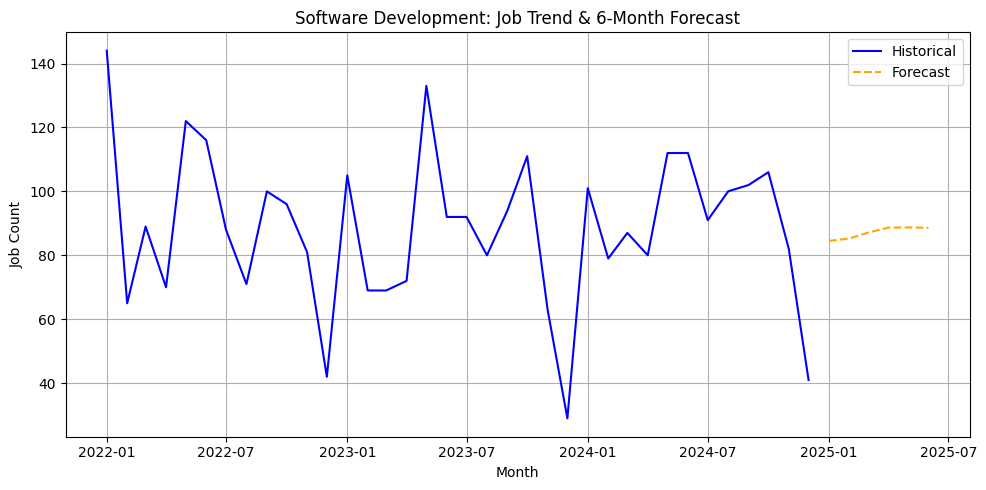

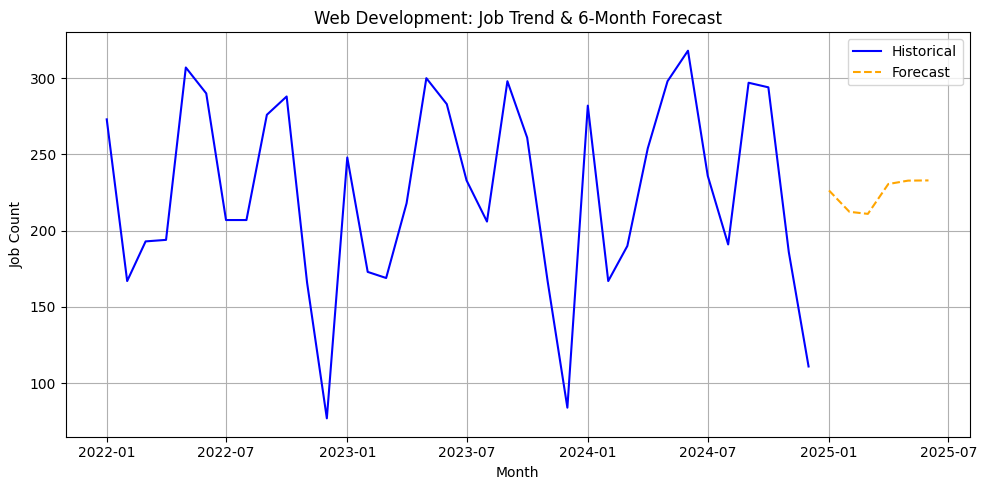

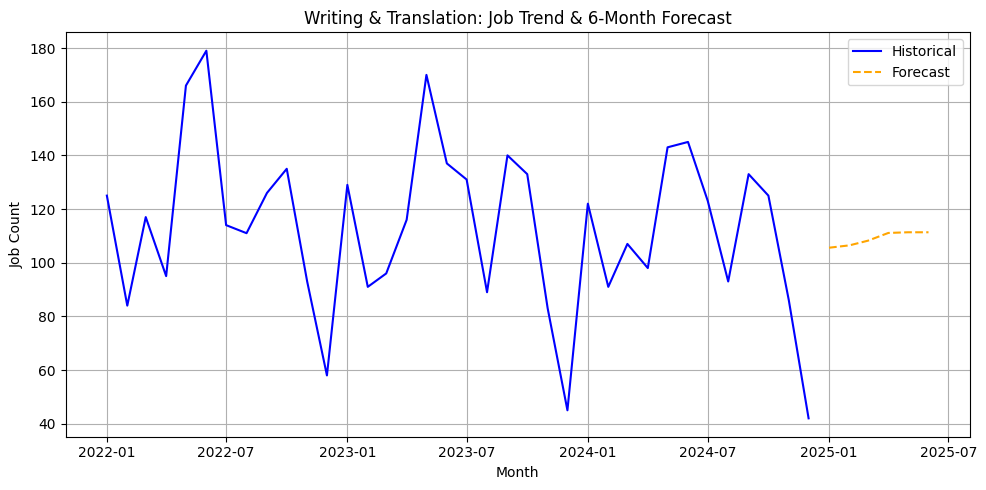

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Loop over each category and plot separately
for category, forecast in predictions.items():
    plt.figure(figsize=(10, 5))

    # Historical data
    history = monthly_counts[category]

    # Forecast data
    future = pd.Series(forecast, index=forecast_months)

    # Plot
    plt.plot(history.index, history.values, label="Historical", color='blue')
    plt.plot(future.index, future.values, '--', label="Forecast", color='orange')

    plt.title(f"{category}: Job Trend & 6-Month Forecast")
    plt.xlabel("Month")
    plt.ylabel("Job Count")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

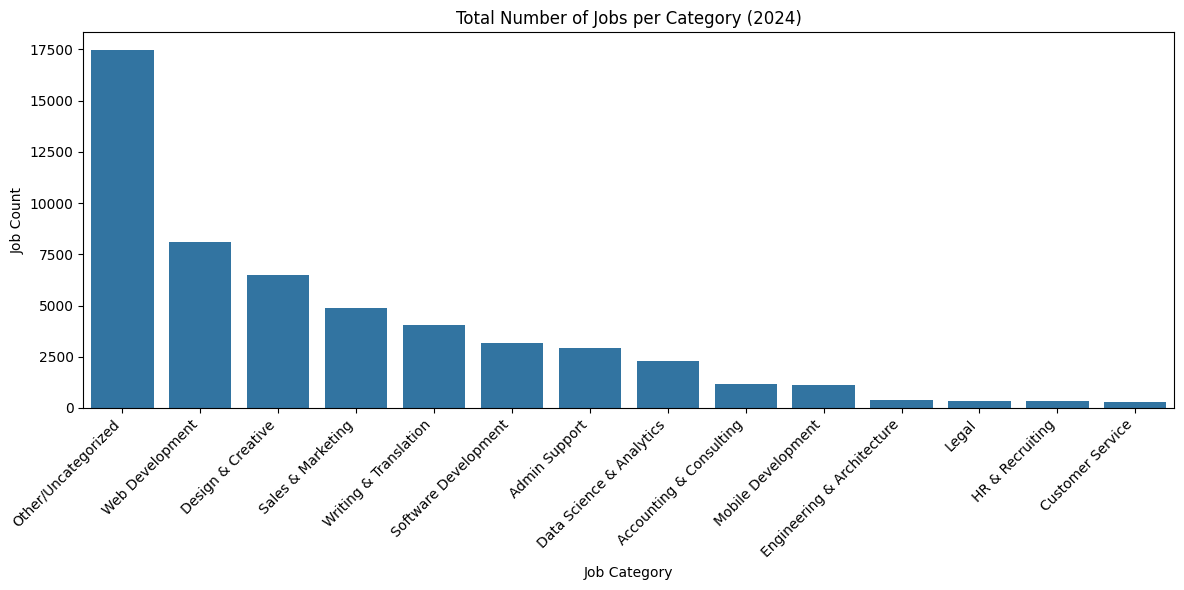

In [ ]:
total_jobs = df['category'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=total_jobs.index, y=total_jobs.values)
plt.xticks(rotation=45, ha='right')
plt.title("Total Number of Jobs per Category (2024)")
plt.ylabel("Job Count")
plt.xlabel("Job Category")
plt.tight_layout()
plt.show()